# Fase 7: Cartografía
**Tema**: 2. Centralidad y corredores críticos de la red vial
**Requisito de Rúbrica**: Mínimo 3 mapas con escala, norte, leyenda y paleta coherente.

En esta fase generaremos visualizaciones de alta calidad de nuestro grafo enriquecido. Crearemos una función auxiliar para añadir elementos cartográficos a las figuras de `matplotlib`.

In [1]:
import osmnx as ox
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import os

G = ox.load_graphml("../data/miraflores_drive_centralities.graphml")
os.makedirs("../docs/img", exist_ok=True)

def add_cartography_elements(ax, title, legend_elements, scale_len_m=1000, scale_label="1 km"):
    """Añade título, flecha de norte, escala y leyenda al gráfico."""
    ax.set_title(title, fontsize=16, weight='bold', pad=20)
    
    # 1. Flecha de Norte
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    
    x_north = x_min + 0.95 * (x_max - x_min)
    y_north = y_min + 0.90 * (y_max - y_min)
    
    ax.annotate('N', xy=(x_north, y_north), xytext=(x_north, y_north - (y_max - y_min)*0.05),
                arrowprops=dict(facecolor='black', width=4, headwidth=10),
                ha='center', va='center', fontsize=14, weight='bold', zorder=5)
                
    # 2. Barra de Escala (EPSG:32718 es en metros)
    x_scale = x_min + 0.05 * (x_max - x_min)
    y_scale = y_min + 0.05 * (y_max - y_min)
    
    ax.plot([x_scale, x_scale + scale_len_m], [y_scale, y_scale], color='black', linewidth=3, zorder=5)
    ax.text(x_scale + scale_len_m/2, y_scale + (y_max - y_min)*0.01, scale_label, 
            ha='center', va='bottom', fontsize=12, weight='bold', zorder=5)
            
    # 3. Leyenda
    if legend_elements:
        ax.legend(handles=legend_elements, loc='lower right', fontsize=12, framealpha=0.9)


## Mapa 1: Morfología Básica y Nodos Críticos

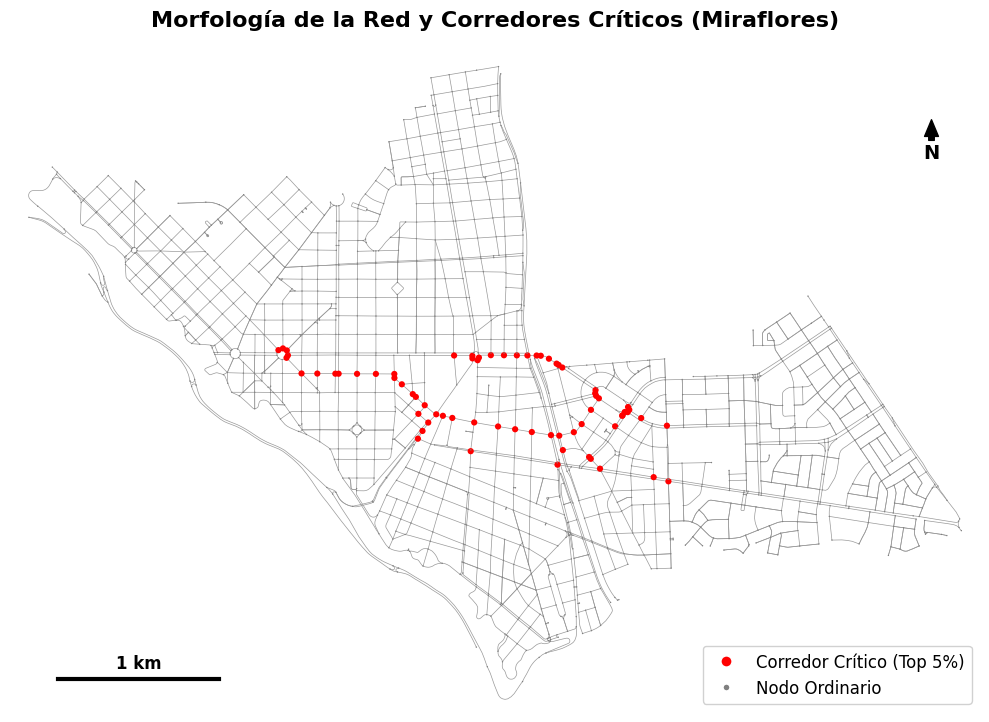

In [2]:
nc = ['red' if int(float(d.get('is_critical', 0))) == 1 else 'gray' for _, d in G.nodes(data=True)]
ns = [20 if int(float(d.get('is_critical', 0))) == 1 else 1 for _, d in G.nodes(data=True)]

fig, ax = plt.subplots(figsize=(10,10), facecolor='white')
fig, ax = ox.plot_graph(G, node_color=nc, node_size=ns, edge_linewidth=0.5, edge_color='#999999', 
                        show=False, close=False, ax=ax)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Corredor Crítico (Top 5%)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=5, label='Nodo Ordinario')
]

add_cartography_elements(ax, "Morfología de la Red y Corredores Críticos (Miraflores)", legend_elements)
plt.tight_layout()
fig.savefig("../docs/img/mapa1_morfologia_critica.png", dpi=300, bbox_inches='tight')
plt.show()

## Mapa 2: Mapa de Calor de Intermediación

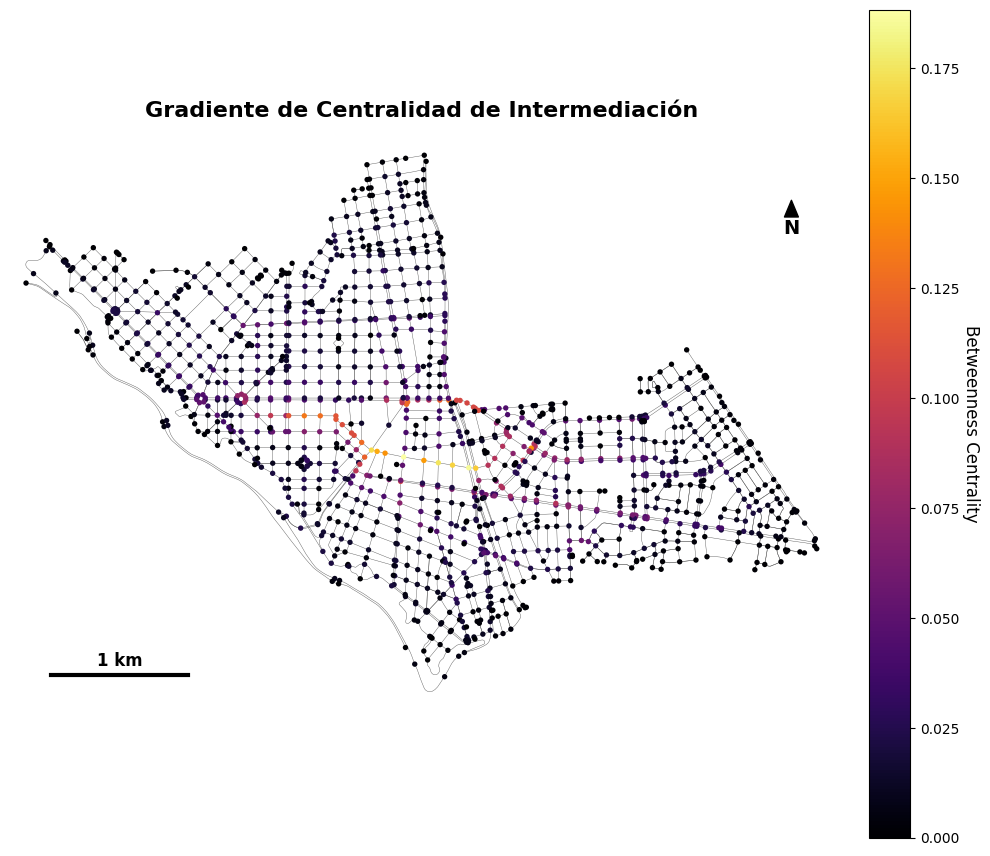

In [3]:
bc_values = [float(d.get('betweenness', 0)) for _, d in G.nodes(data=True)]
fig, ax = plt.subplots(figsize=(10,10), facecolor='white')

# Colormap inferno manual
cmap = plt.colormaps.get_cmap('inferno')
norm = plt.Normalize(vmin=min(bc_values), vmax=max(bc_values))
nc = [cmap(norm(v)) for v in bc_values]

fig, ax = ox.plot_graph(G, node_color=nc, node_size=15, 
                        edge_linewidth=0.3, edge_color='#555555', 
                        show=False, close=False, ax=ax)

sm = plt.cm.ScalarMappable(cmap='inferno', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Betweenness Centrality', rotation=270, labelpad=15, fontsize=12)

add_cartography_elements(ax, "Gradiente de Centralidad de Intermediación", legend_elements=None)
plt.tight_layout()
fig.savefig("../docs/img/mapa2_heatmap_betweenness.png", dpi=300, bbox_inches='tight')
plt.show()

## Mapa 3: Integración de Puntos de Interés (POI)

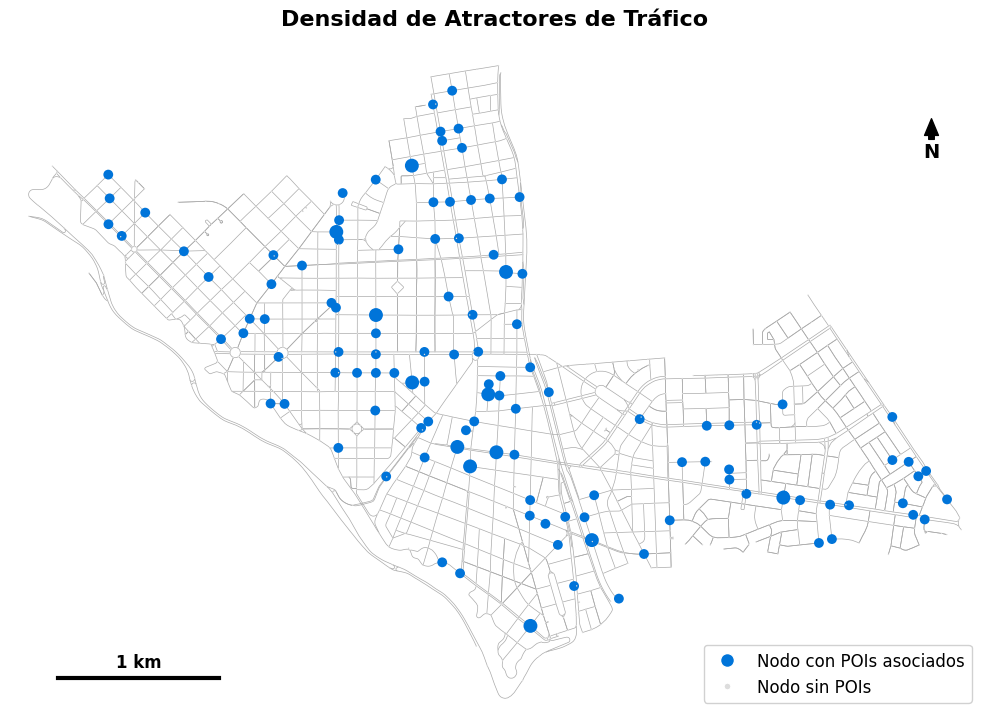

In [4]:
poi_counts = [int(float(d.get('poi_count', 0))) for _, d in G.nodes(data=True)]

ns = [50 * count if count > 0 else 1 for count in poi_counts]
nc = ['#0074D9' if count > 0 else '#DDDDDD' for count in poi_counts]

fig, ax = plt.subplots(figsize=(10,10), facecolor='white')
fig, ax = ox.plot_graph(G, node_color=nc, node_size=ns, edge_linewidth=0.5, edge_color='#AAAAAA',
                        show=False, close=False, ax=ax)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#0074D9', markersize=10, label='Nodo con POIs asociados'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#DDDDDD', markersize=5, label='Nodo sin POIs')
]

add_cartography_elements(ax, "Densidad de Atractores de Tráfico", legend_elements)
plt.tight_layout()
fig.savefig("../docs/img/mapa3_poi_integration.png", dpi=300, bbox_inches='tight')
plt.show()